In [2]:
from functools import partial

import colorcet as cc
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from dynamical_systems.continuous import Lorenz63, solve_ode, TangentODE
from dynamical_systems.metrics.lyapunov import (
    lyapunov_gr,
    lyapunov_naive,
    lyapunov_nonlinear,
)
from dynamics_discovery.dataset import TimeSeriesDataset
from dynamics_discovery.models import NeuralODE
from jaxtyping import Array, Float
from matplotlib_utils.axes_setters import set_labels


jax.config.update("jax_enable_x64", True)

ModuleNotFoundError: No module named 'dynamical_systems.metrics'

In [2]:
lorenz = Lorenz63()
dataset_loaded = TimeSeriesDataset.load("./data/lorenz.hdf5")
u0 = dataset_loaded.u0[0]

In [3]:
lorenz_tangent = TangentODE(lorenz)
u0_tangent = (u0, jnp.identity(lorenz.dim))

jnp.all(
    jnp.isclose(
        lorenz_tangent.rhs(0.0, u0_tangent, None)[1],
        lorenz.jacobian(0.0, u0_tangent[0], None),
    )
)

Array(True, dtype=bool)

In [4]:
t = jnp.arange(0, 50, 0.01)
lya_naive, _ = lyapunov_naive(lorenz, dataset_loaded.u0[0], t)
lya_gr, _ = lyapunov_gr(lorenz, dataset_loaded.u0[0], t)
lya_nonlinear, _ = lyapunov_nonlinear(lorenz, dataset_loaded.u0[0], t)

In [5]:
lya_nonlinear.shape

(5000,)

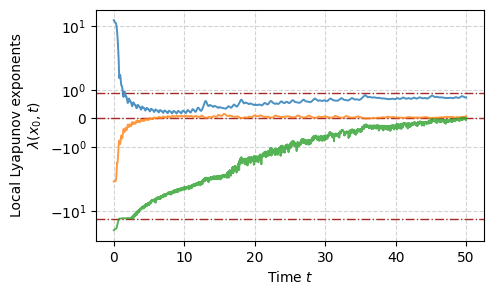

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# ax.set_yscale("symlog", base=10)

lya_known = (0.9057, 1.4e-5, -14.5724)
for lya_true in lya_known:
    ax.axhline(
        y=lya_true,
        color="brown",
        linewidth=1.0,
        linestyle="-.",
    )

plot_kwargs = {"linewidth": 1.4, "alpha": 0.8}
ax.plot(t, lya_naive[:, 0], **plot_kwargs)
ax.plot(t, lya_naive[:, 1], **plot_kwargs)
ax.plot(t, lya_naive[:, 2], **plot_kwargs)

ax.set_xlabel("Time $t$")
ax.set_ylabel("Local Lyapunov exponents\n" + r"$\lambda(x_0, t)$")
ax.grid(ls="--", color="lightgray")
ax.set_yscale("symlog")

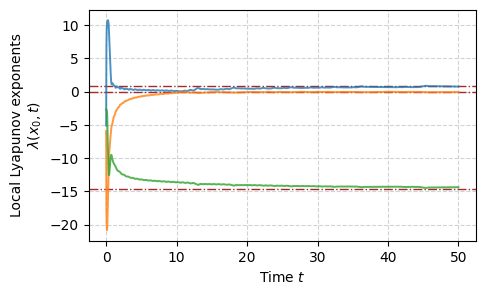

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# ax.set_yscale("symlog", base=10)

lya_known = (0.9057, 1.4e-5, -14.5724)
for lya_true in lya_known:
    ax.axhline(
        y=lya_true,
        color="brown",
        linewidth=1.0,
        linestyle="-.",
    )

plot_kwargs = {"linewidth": 1.4, "alpha": 0.8}
ax.plot(t, lya_gr[:, 0], **plot_kwargs)
ax.plot(t, lya_gr[:, 1], **plot_kwargs)
ax.plot(t, lya_gr[:, 2], **plot_kwargs)

ax.set_xlabel("Time $t$")
ax.set_ylabel("Local Lyapunov exponents\n" + r"$\lambda(x_0, t)$")
ax.grid(ls="--", color="lightgray")
# ax.set_yscale("symlog")

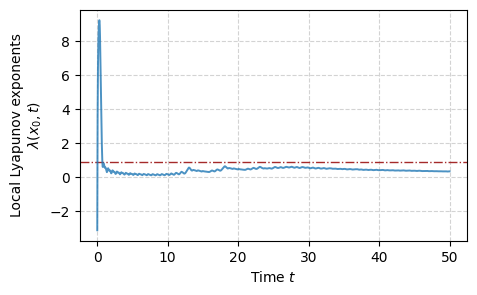

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# ax.set_yscale("symlog", base=10)

lya_known = (0.9057, 1.4e-5, -14.5724)

ax.axhline(
    y=lya_known[0],
    color="brown",
    linewidth=1.0,
    linestyle="-.",
)
plot_kwargs = {"linewidth": 1.4, "alpha": 0.8}
ax.plot(t, lya_nonlinear, **plot_kwargs)


ax.set_xlabel("Time $t$")
ax.set_ylabel("Local Lyapunov exponents\n" + r"$\lambda(x_0, t)$")
ax.grid(ls="--", color="lightgray")
# ax.set_yscale("symlog")

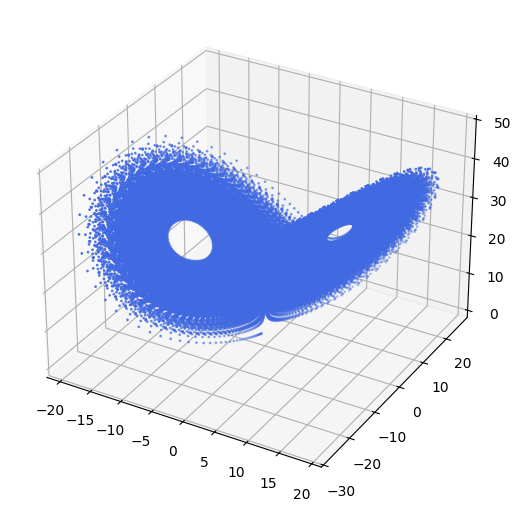

In [10]:
u_train = dataset_loaded.u[0]
u_train_coarse = u_train[::1,]

fig, ax = plt.subplots(
    1,
    1,
    figsize=(8, 5),
    constrained_layout=True,
    subplot_kw={"projection": "3d"},
)
ax.scatter(*u_train_coarse.T, ".", s=1, color="royalblue")

In [11]:
t = jnp.arange(0, 10, 0.1)
lya_local, _ = eqx.filter_vmap(lyapunov_nonlinear, in_axes=(None, 0, None))(
    lorenz, u_train_coarse, t
)
lya_mean = jnp.mean(lya_local, axis=0)

2025-04-06 18:31:07.300234: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3021] Can't reduce memory use below 15.13GiB (16249487632 bytes) by rematerialization; only reduced to 31.22GiB (33519200432 bytes), down from 31.22GiB (33519200432 bytes) originally


In [14]:
t = jnp.arange(0, 10, 0.1)
lya_local, _ = eqx.filter_vmap(in_axes=(None, 0, None))(lyapunov_gr)(
    lorenz, u_train_coarse, t
)

In [15]:
lya_local.shape

(100000, 100, 3)

Text(0.5, 0.01, 'Time $t$')

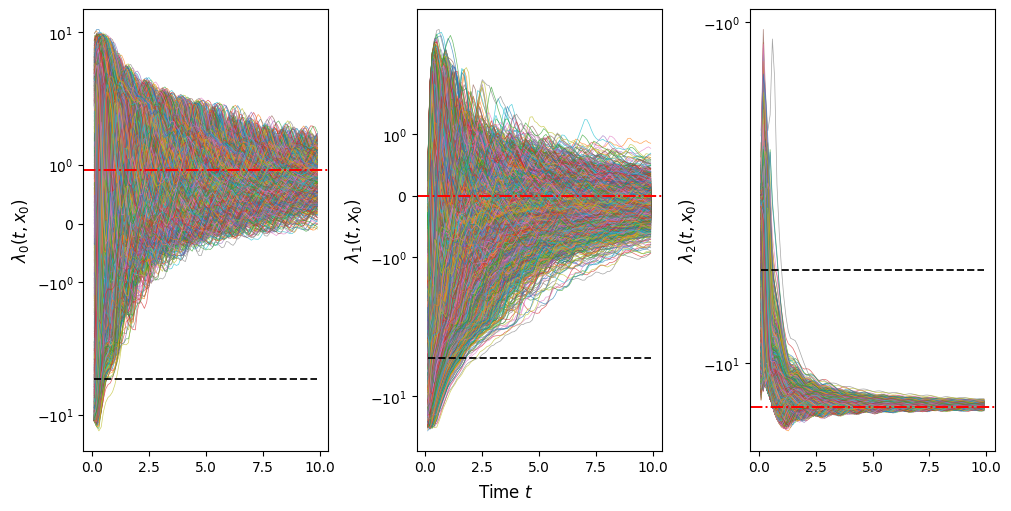

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharex=True, constrained_layout=True)
lya_mean = jnp.mean(lya_local, axis=-1)
lya_known = (0.9057, 1.4e-5, -14.5724)

for i, ax in enumerate(axes):
    for lya_i in lya_local[::10]:
        ax.plot(t, lya_i[:, i], linewidth=0.5, alpha=0.7)
    ax.axhline(
        y=lya_known[i],
        color="red",
        linewidth=1.4,
        linestyle="-.",
    )
    ax.plot(t, lya_mean[i], "--", color="black", linewidth=1.4, alpha=0.9)
    ax.set_ylabel(rf"$\lambda_{i}(t, x_0)$", fontsize="large")
    ax.set_yscale("symlog", base=10)
fig.supxlabel("Time $t$")

In [12]:
t_batch = jnp.log(2) / lya_local

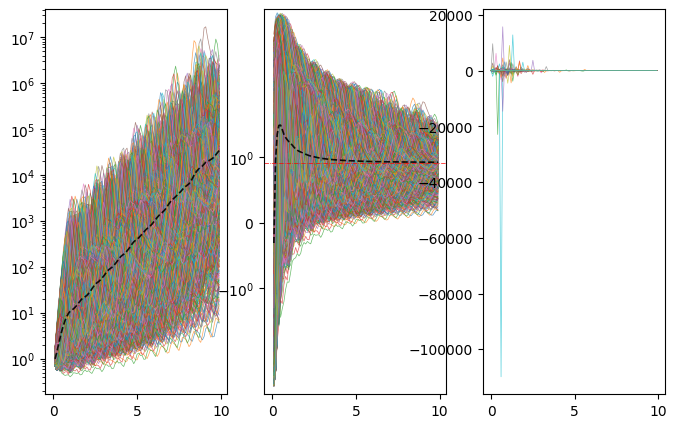

In [13]:
rel_error_norm = jnp.exp(lya_local * t)

fig, axes = plt.subplots(1, 3, figsize=(8, 5), sharex=True)
for lya_i, err_i, t_i in zip(lya_local[::10], rel_error_norm[::10], t_batch[::10]):
    axes[0].plot(t, err_i, linewidth=0.5, alpha=0.7)
    axes[1].plot(t, lya_i, linewidth=0.5, alpha=0.7)
    axes[2].plot(t, t_i, linewidth=0.5, alpha=0.7)
axes[0].plot(
    t, jnp.mean(rel_error_norm, axis=0), "--", color="black", linewidth=1.2, alpha=0.9
)
axes[1].plot(t, lya_mean, "--", color="black", linewidth=1.2, alpha=0.9)
axes[0].set_yscale("log", base=10)
axes[1].set_yscale("symlog", base=10)
axes[1].axhline(
    y=0.90566,
    color="red",
    linewidth=0.5,
    linestyle="-.",
)


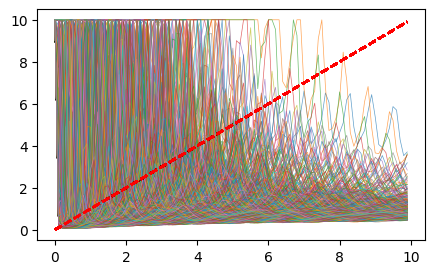

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
T_BATCH_MAX = 10
t_batch_mod = jnp.clip(t_batch, max=T_BATCH_MAX)
t_batch_mod = t_batch_mod.at[t_batch_mod <= 0].set(T_BATCH_MAX)
for t_i in t_batch_mod[::10]:
    ax.plot(t, t_i, linewidth=0.5, alpha=0.7)
    ax.plot(t, t, "--", color="red")


In [16]:
islarger = t_batch_mod < t
good_inds = islarger.shape[1] - jnp.argmin(islarger[:, ::-1], axis=-1)

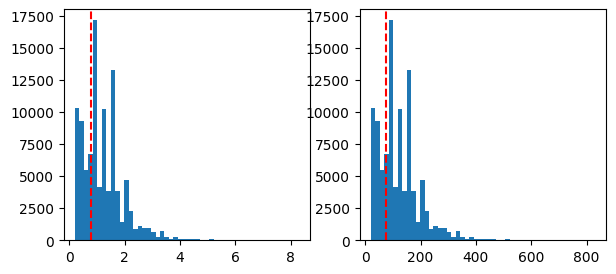

In [17]:
t_batch_consistent = t[good_inds]
n_batch_consistent = jnp.round(t_batch_consistent * 100)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].hist(t_batch_consistent, bins=50)
axes[0].axvline(x=0.77, linestyle="--", color="red")
axes[1].hist(n_batch_consistent, bins=50)
axes[1].axvline(x=77, linestyle="--", color="red")

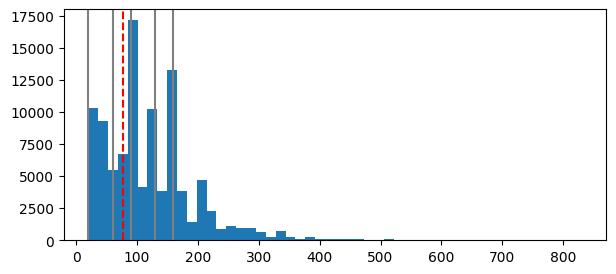

In [18]:
t_batch_consistent = t[good_inds]
n_batch_consistent = jnp.round(t_batch_consistent * 100)

n_coarse = 5
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.hist(n_batch_consistent, bins=50)
ax.axvline(x=77, linestyle="--", color="red")
for i in range(n_coarse):
    ax.axvline(
        x=jnp.percentile(n_batch_consistent, 100 * i / (n_coarse)),
        linestyle="-",
        color="gray",
    )

In [19]:
batch_bins = jnp.percentile(n_batch_consistent, jnp.arange(n_coarse) * 100 / n_coarse)
n_batch_coarse_inds = jnp.digitize(n_batch_consistent, batch_bins) - 1
n_batch_coarse = batch_bins[n_batch_coarse_inds]

In [146]:
jnp.savez("./data/lorenz_local_lyapunov.npz", t=t, lya_local=lya_local)

In [77]:
lya_local[0]

Array([      -inf, 0.6457658 , 0.2152041 , 0.25847287, 0.22643675,
       0.16250884, 0.18723723, 0.11155589, 0.15776289, 0.13605421,
       0.17941554, 0.18515556, 0.32445531, 0.56945527, 0.38196936,
       0.36225917, 0.3274927 , 0.45237081, 0.61225631, 0.51547543,
       0.47708893, 0.43435869, 0.51407334, 0.59890378, 0.51272957,
       0.55190426, 0.59438038, 0.58720361, 0.56056531, 0.57958907,
       0.55254351, 0.50988545, 0.52279275, 0.52033977, 0.47990767,
       0.47790534, 0.46512467, 0.45094625, 0.43573134, 0.42673595,
       0.40664816, 0.40447945, 0.39919812, 0.38150826, 0.37785473,
       0.37821842, 0.35602596, 0.35192826, 0.3511469 , 0.33597471],      dtype=float64)

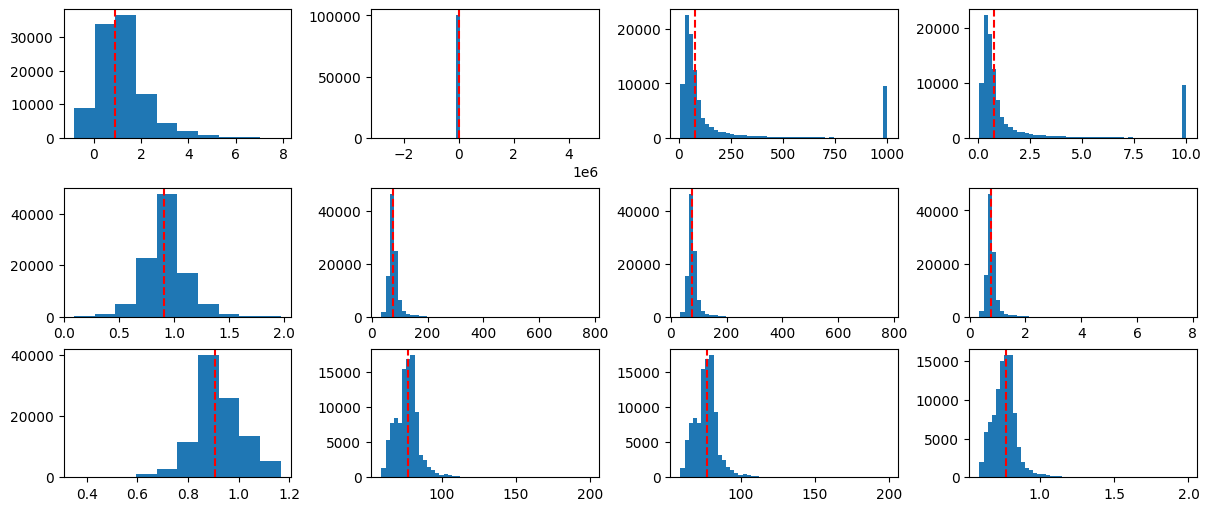

In [39]:
fig, axes = plt.subplots(3, 4, figsize=(12, 5), constrained_layout=True)
inds_time = (1, 7, 15)
for i, (ind, ax) in enumerate(zip(inds_time, axes[:, 0])):
    ax.hist(lya_local[:, ind], bins=10)
    ax.axvline(x=0.90566, linestyle="--", color="red")

dt = dataset_loaded.t[1] - dataset_loaded.t[0]
batch_lengths = jnp.round(jnp.log(2) / (lya_local * dt))

for i, (ind, ax) in enumerate(zip(inds_time, axes[:, 1])):
    ax.hist(batch_lengths[:, ind], bins=50)
    ax.axvline(x=77, linestyle="--", color="red")

MAX_BATCH_LENGTH = 1000
batch_lengths_mod = jnp.clip(batch_lengths, max=MAX_BATCH_LENGTH)
batch_lengths_mod = batch_lengths_mod.at[batch_lengths_mod < 0].set(MAX_BATCH_LENGTH)

for i, (ind, ax) in enumerate(zip(inds_time, axes[:, 2])):
    ax.hist(batch_lengths_mod[:, ind], bins=50)
    ax.axvline(x=77, linestyle="--", color="red")

for i, (ind, ax) in enumerate(zip(inds_time, axes[:, 3])):
    ax.hist(t_batch_mod[:, ind], bins=50)
    ax.axvline(x=0.77, linestyle="--", color="red")

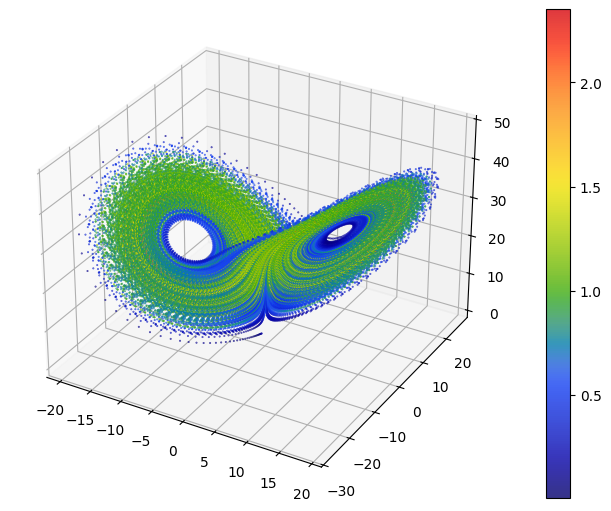

In [ ]:
idx_time = 5
fig, ax = plt.subplots(
    1,
    1,
    figsize=(8, 5),
    constrained_layout=True,
    subplot_kw={"projection": "3d"},
)
sc = ax.scatter(
    *u_train_coarse.T,
    ".",
    c=lya_local[:, idx_time],
    s=0.2,
    alpha=0.8,
    cmap=cc.cm.rainbow4,
)
fig.colorbar(sc)

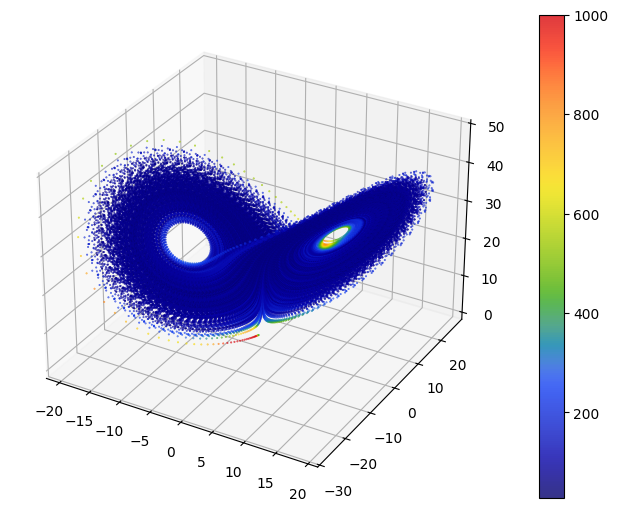

In [151]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(8, 5),
    constrained_layout=True,
    subplot_kw={"projection": "3d"},
)
sc = ax.scatter(
    *u_train_coarse.T,
    ".",
    c=batch_lengths_mod[:, idx_time],
    s=0.2,
    alpha=0.8,
    cmap=cc.cm.rainbow4,
)
fig.colorbar(sc)

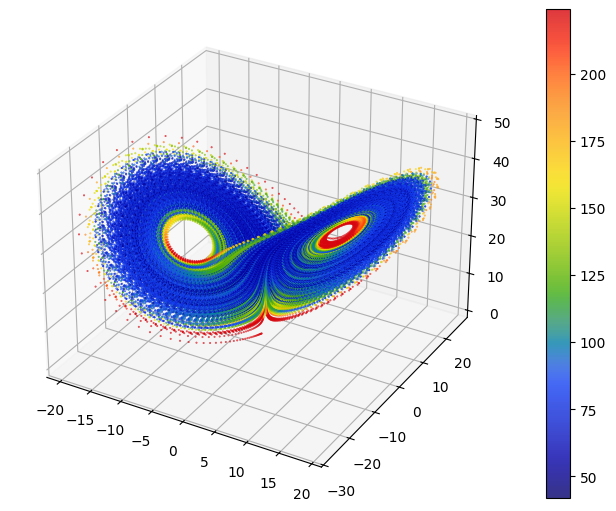

In [152]:
clip_percentile = 1
fig, ax = plt.subplots(
    1, 1, figsize=(8, 5), constrained_layout=True, subplot_kw={"projection": "3d"}
)
batch_lengths_clipped = jnp.clip(
    batch_lengths_mod[:, idx_time],
    min=jnp.percentile(batch_lengths_mod[:, idx_time], clip_percentile),
    max=jnp.percentile(batch_lengths_mod[:, idx_time], 100 - clip_percentile),
)
sc = ax.scatter(
    *u_train_coarse.T,
    ".",
    c=batch_lengths_clipped,
    s=0.2,
    alpha=0.8,
    cmap=cc.cm.rainbow4,
)
fig.colorbar(sc)

In [157]:
batch_len_sorted = jnp.sort(batch_lengths_clipped)
batch_len_gap = jnp.unique(batch_len_sorted[1:] - batch_len_sorted[0:-1])

In [158]:
batch_len_gap

Array([0., 1.], dtype=float64)

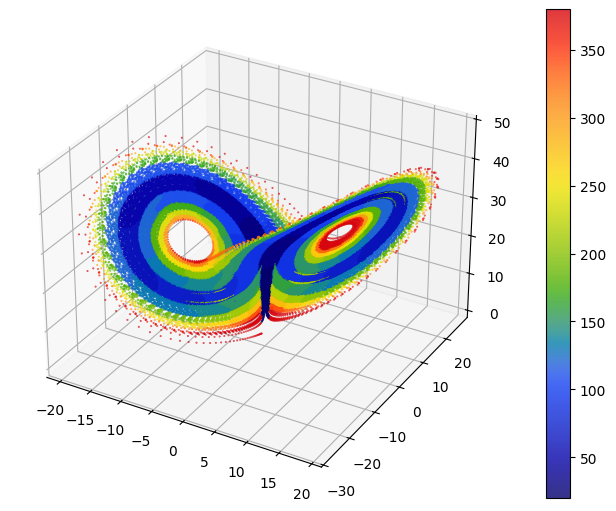

In [ ]:
import colorcet as cc


clip_percentile = 1
fig, ax = plt.subplots(
    1, 1, figsize=(8, 5), constrained_layout=True, subplot_kw={"projection": "3d"}
)
batch_lengths_clipped = jnp.clip(
    n_batch_consistent,
    min=jnp.percentile(n_batch_consistent, clip_percentile),
    max=jnp.percentile(n_batch_consistent, 100 - clip_percentile),
)
sc = ax.scatter(
    *u_train_coarse.T,
    ".",
    c=batch_lengths_clipped,
    s=0.2,
    alpha=0.8,
    cmap=cc.cm.rainbow4,
)
fig.colorbar(sc)

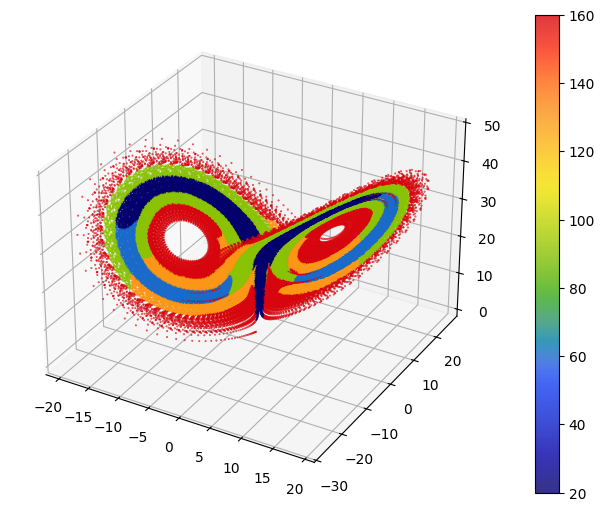

In [ ]:
import colorcet as cc


clip_percentile = 1
fig, ax = plt.subplots(
    1, 1, figsize=(8, 5), constrained_layout=True, subplot_kw={"projection": "3d"}
)
sc = ax.scatter(
    *u_train_coarse.T,
    ".",
    c=n_batch_coarse,
    s=0.2,
    alpha=0.8,
    cmap=cc.cm.rainbow4,
)
fig.colorbar(sc)

In [22]:
batch_bins

Array([ 20.,  60.,  90., 130., 160.], dtype=float64)

In [45]:
u_train_mean = jnp.mean(u_train_coarse, axis=0)
u_train_std = jnp.std(u_train_coarse, axis=0)
u_train_coarse_norm = (u_train_coarse - u_train_mean) / u_train_std

In [ ]:
current_ind = 0
batch_dict_t = {int(k): [] for k in batch_bins}
batch_dict = {int(k): [] for k in batch_bins}
while current_ind < u_train_coarse_norm.shape[0]:
    current_batch_size = int(n_batch_coarse[current_ind])
    next_ind = current_ind + current_batch_size
    if next_ind >= u_train_coarse_norm.shape[0]:
        # break
        continue
    batch_dict_t[current_batch_size].append(dataset_loaded.t[current_ind:next_ind])
    batch_dict[current_batch_size].append(u_train_coarse_norm[current_ind:next_ind])
    # current_ind = next_ind
    current_ind += 1
batch_dict

In [30]:
batch_dict_t = {k: jnp.stack(v, axis=0) for k, v in batch_dict_t.items()}
batch_dict = {k: jnp.stack(v, axis=0) for k, v in batch_dict.items()}

In [31]:
t_train_chunked = list(batch_dict_t.values())
u_train_chunked = list(batch_dict.values())

In [32]:
@eqx.filter_jit
@partial(eqx.filter_vmap, in_axes=(None, 0, 0))
def solve_neuralode(model, t, u0):
    u_pred = solve_ode(
        model,
        t,
        u0,
        rtol=1e-4,
        atol=1e-4,
        max_steps=2048,
        adjoint=dfx.RecursiveCheckpointAdjoint(checkpoints=4096),
    )
    return u_pred


def loss_mse(
    model,
    t_data: Float[Array, "batch time"],
    u_data: Float[Array, "batch time dim"],
    u0_data=None,
):
    del u0_data
    u_pred = solve_neuralode(model, t_data, u_data[:, 0])
    return jnp.mean((u_pred - u_data) ** 2)


def loss_mse_total(
    model,
    t_data: list[Float[Array, "batch time"]],
    u_data: list[Float[Array, "batch time dim"]],
    u0_data=None,
):
    del u0_data
    loss = 0
    for t_data_i, u_data_i in zip(t_data, u_data):
        loss = loss + loss_mse(model, t_data_i, u_data_i)
    return loss / len(t_data)

In [33]:
key = 0
model = NeuralODE(3, 32, 3, key=key)
loss_mse_total(model, t_train_chunked, u_train_chunked)

Array(1.04816901, dtype=float64)

In [ ]:
from main import train_vanilla


model = train_vanilla(
    model,
    t_train_chunked,
    u_train_chunked,
    None,
    loss_mse_total,
    wandb_entity="jhko725",
    wandb_project="teacher-sync",
    wandb_config={"preprocessing.batch_length": "local_lyapunov", "model.key": key},
)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: jhko725 (jhelab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


epoch=0, loss=Array(1.04816901, dtype=float64)
epoch=1, loss=Array(1.0439404, dtype=float64)
epoch=2, loss=Array(1.03963129, dtype=float64)
epoch=3, loss=Array(1.03524464, dtype=float64)
epoch=4, loss=Array(1.03077759, dtype=float64)
epoch=5, loss=Array(1.02622366, dtype=float64)
epoch=6, loss=Array(1.02157305, dtype=float64)
epoch=7, loss=Array(1.01681133, dtype=float64)
epoch=8, loss=Array(1.01191942, dtype=float64)
epoch=9, loss=Array(1.00687405, dtype=float64)
epoch=10, loss=Array(1.00164857, dtype=float64)
epoch=11, loss=Array(0.99621384, dtype=float64)
epoch=12, loss=Array(0.9905391, dtype=float64)
epoch=13, loss=Array(0.98459268, dtype=float64)
epoch=14, loss=Array(0.97834287, dtype=float64)
epoch=15, loss=Array(0.97175874, dtype=float64)
epoch=16, loss=Array(0.96481089, dtype=float64)
epoch=17, loss=Array(0.95747244, dtype=float64)
epoch=18, loss=Array(0.94971996, dtype=float64)
epoch=19, loss=Array(0.94153457, dtype=float64)
epoch=20, loss=Array(0.93290309, dtype=float64)
epoc

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇████
loss,█▇▆▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▂▂▂▂▂▂
epoch,4999
loss,0.14929


In [41]:
model[0]

NeuralODE(
  in_size=3,
  width_size=32,
  depth=3,
  out_size=3,
  net=MLP(
    layers=(
      Linear(
        weight=f64[32,3],
        bias=f64[32],
        in_features=3,
        out_features=32,
        use_bias=True
      ),
      Linear(
        weight=f64[32,32],
        bias=f64[32],
        in_features=32,
        out_features=32,
        use_bias=True
      ),
      Linear(
        weight=f64[32,32],
        bias=f64[32],
        in_features=32,
        out_features=32,
        use_bias=True
      ),
      Linear(
        weight=f64[3,32],
        bias=f64[3],
        in_features=32,
        out_features=3,
        use_bias=True
      )
    ),
    activation=<function gelu>,
    final_activation=<function <lambda>>,
    use_bias=True,
    use_final_bias=True,
    in_size=3,
    out_size=3,
    width_size=32,
    depth=3
  ),
  dim=3
)

In [ ]:
from pathlib import Path


eqx.tree_serialise_leaves(
    Path("./results") / f"lorenz_length=local_lyapunov_key={key}.eqx",
    model[0],
)

In [38]:
u_test = (dataset_loaded.u[1] - u_train_mean) / u_train_std

In [43]:
u_pred_test = solve_ode(model[0], t, u_test[0], max_steps=None)

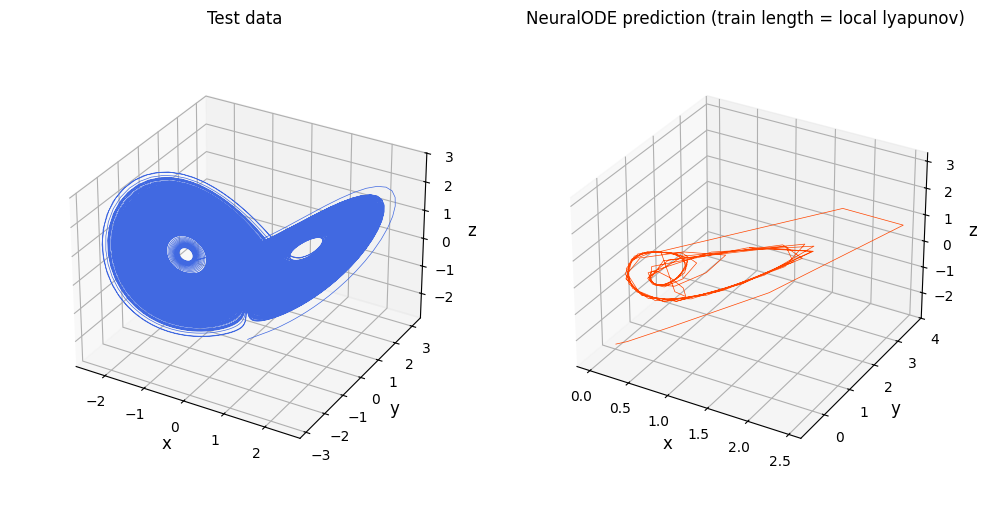

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5),
    constrained_layout=True,
    subplot_kw={"projection": "3d"},
)
plot_kwargs = {"linewidth": 0.5}
axes[0].plot(*u_test.T, color="royalblue", **plot_kwargs)
axes[0].set_title("Test data")
axes[1].plot(*u_pred_test.T, color="orangered", **plot_kwargs)
axes[1].set_title("NeuralODE prediction (train length = local lyapunov)")
for ax in axes:
    set_labels(ax, ["x", "y", "z"], fontsize="large")
    ax.set_box_aspect(None, zoom=0.85)